# Notebook Instructions

1. If you are new to Jupyter notebooks, please go through this introductory manual <a href='https://quantra.quantinsti.com/quantra-notebook' target="_blank">here</a>.
1. Any changes made in this notebook would be lost after you close the browser window. **You can download the notebook to save your work on your PC.**
1. Before running this notebook on your local PC:<br>
i.  You need to set up a Python environment and the relevant packages on your local PC. To do so, go through the section on "**Run Codes Locally on Your Machine**" in the course.<br>
ii. You need to **download the zip file available in the last unit** of this course. The zip file contains the data files and/or python modules that might be required to run this notebook.

# Detecting Head and Shoulders

Previously, you learnt how to programmatically identify the local minima and maxima points for the price series of your favourite asset. Through this notebook, we will perform some additional steps in order to detect the presence of the head and shoulders patterns based on local minima and maxima points.


This notebook is structured as follows:
1. [Import Libraries](#libraries)
2. [Read the Data](#data)
3. [Detect the Local Minima and Maxima](#min-max)
4. [Create a Head and Shoulders Scanner](#hs-scanner)
5. [Store the Pattern Details](#pattern-details)
6. [Visualise the Head and Shoulders Pattern](#visualise)
7. [Conclusion and Next Steps](#conclusion)

<a id='libraries'></a>
## Import Libraries

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np

# For visualisation
import mplfinance as mpf

# To ignore warnings
import warnings
warnings.filterwarnings("ignore")

<a id='data'></a>
## Read the Data

Import the file `spy_daily_1993_2018.csv` using the `read_csv` method of `pandas`. This file has the OHLCV values for SPY ETF in the daily frequency. This CSV file is available in the zip file of the unit 'Python Codes and Data' in the 'Course Summary' section.

In [2]:
# Import the stock price data
data = pd.read_csv(
    '../data_modules/spy_daily_1993_2018.csv', index_col=0)

# Change the index type to datetime
data.index = pd.to_datetime(data.index)

# Display the data
data.tail()

,Open,High,Low,Close,Volume
Date,,,,,
2018-12-24,224.666298,226.358066,220.183133,220.248917,147311600
2018-12-26,221.780913,231.376968,219.703796,231.376968,218485400
2018-12-27,227.984041,233.360078,224.591113,233.153320,186267300
2018-12-28,234.572501,236.283055,231.630707,232.852539,153100200
2018-12-31,234.553721,235.145843,232.589398,234.892075,144299400


<a id='min-max'></a>
## Detect the Local Minima and Maxima

In the previous notebook, we created a function called `get_min_max` which computes and returns the local minima and maxima points. This function has been saved into a python file called `price_action_util_quantra` under the `data_modules` folder and you can easily access it whenever required. 

In [3]:
# Helper function
import sys
sys.path.append('..')
from data_modules.price_action_util_quantra import get_min_max

In the above cell, we imported the `get_min_max` function. Next, let's quickly fetch the local minima and maxima points by using this function.

Syntax:
```python
local_max_min(data, argrel_window)
```

Parameters:
* `data`: You can pass either of the `Open`, `High`, `Low` or `Close` price series as input. 
* `argrel_window`: Here you can specify the number of points on each side that you want to consider for the comparison. We will set the value of the argrel function as 5. However, note that 5 has been chosen arbitrarily and you can set it to any number you prefer. 

Returns:
* Two series of data points - which consist of either minima values or maxima values along with their corresponding dates.

In [4]:
# Fetch dataframes of minima and maxima values
minima_prices, maxima_prices = get_min_max(data, 5)

# Display the minima values
minima_prices[:5]

Date
1993-02-18    24.685349
1993-03-22    25.815740
1993-04-06    25.526094
1993-04-26    25.073494
1993-05-19    25.399360
Name: Low, dtype: float64

In [5]:
# Display the maxima values
maxima_prices[:5]

Date
1993-02-08    26.018727
1993-03-11    26.433165
1993-03-31    26.340743
1993-04-13    26.159724
1993-05-05    25.924356
Name: High, dtype: float64

<a id='hs-scanner'></a>
## Create a Head and Shoulders Scanner

We already have the values of the local minima and maxima points for the price series data. Now let us proceed to the most important step which is creating a scanner function to detect head and shoulders patterns in our data. 

Now, the first step that we need to take is to identify a set of 5 minima as well as maxima points that appear in a sequence. So let us quickly combine the existing data of `minima_prices` and `maxima_prices` and sort it based on the index. This will give us the sequential data of both minima and maxima points.

In [6]:
# Store values of both minima and maxima points in a sequential order
min_max = pd.concat([minima_prices, maxima_prices]).sort_index()
min_max[:5]

Date
1993-02-08    26.018727
1993-02-18    24.685349
1993-03-11    26.433165
1993-03-22    25.815740
1993-03-31    26.340743
dtype: float64

A head and shoulders pattern is made up of 5 sequential points as shown below:

![title](https://d2a032ejo53cab.cloudfront.net/Course/Units/Mcq/UnitContent/Ff66xsYC/HS.png)

Next, to classify a sequence of 5 local minima and maxima points (such as A, B, C, D and E in the above figure) as a head and shoulders pattern, we need to confirm whether the following relationship exists between points 5 sequential points:

1. Points **A, C and E** must come under the set of local **maxima points**. This is because they represent the peaks of the head and shoulders.
<br>

2. Points **B and D** should lie in the set of local **minima points**, as they form the neckline of the pattern.
<br>

3. The five sequential points must exhibit a relation as follows:
 * Point **C must lie above points A and E**, since, the peaks of the head must lie above the shoulders.
 * Points **A and E must lie above points B and D** as the peaks of the two shoulders must lie above the neckline points.

<br>
4. The two points A and E (that form the two shoulder peaks) must not lie at a distance greater than 1.5% away from their mean. For example, if the average of A and E is 100, then the difference between A and E must not be greater than 1.5 (which is 1.5% of 100). And the same goes for points B and D (that form the neckline).


You can refer to the book <a href='https://www.google.co.in/books/edition/Advanced_Trading_Rules/27Vo8RPc12wC?hl=en&gbpv=1&dq=patterns%5B%27IHS%27%5D&pg=PA53&printsec=frontcover
' target="_blank">Advanced Trading Rules</a> by Emmanual Acar and Stephen Satchell to get some deeper insights behind the conditions used to detect a head and shoulder pattern.


## Create the Head and Shoulders Scanner

Keeping in mind all of the above conditions, we can create a scanner for the head and shoulders pattern as follows:

In [7]:
def hs_scanner(min_max, minima_prices, maxima_prices, frequency='daily'):

    # To store pattern instances
    patterns = []

    # Loop to iterate along the price data
    for i in range(5, len(min_max)):

        # Store 5 local minima and local maxima points at a time in the variable 'window'
        window = min_max.iloc[i-5:i]

        # Determine window length based on the frequency of data
        if frequency == 'daily':
            window_size = (window.index[-1] - window.index[0]).days
        else:
            window_size = (window.index[-1] - window.index[0]).seconds/60/60

        # Ensure that pattern is formed within 100 bars
        if window_size > 100:
            continue

        # Store the 5 unique points to check for conditions
        a, b, c, d, e = [window[i] for i in range(0, len(window))]

        # cond_1: To check a,c,e are in maxima_prices
        cond_1 = all(x in maxima_prices.values for x in [a, c, e])

        # cond_2: To check b,d are in maxima_prices
        cond_2 = all(x in minima_prices.values for x in [b, d])

        # cond_3: To check if the shoulders are above the neckline and the head is above the shoulders
        cond_3 = (c > a) and (c > e) and (a > b) and (a > d) and (e > b) and (e > d)

        # cond_4: To check if A and E (and also B and D) are at a distance less than 1.5% away from their mean
        cond_4 = (abs(a-e) <= np.mean([a, e]) *
                  0.015) and (abs(b-d) <= np.mean([b, d])*0.015)

        # Checking if all conditions are true
        if cond_1 and cond_2 and cond_3 and cond_4:

            # Append the pattern to list if all conditions are met
            patterns.append(
                ([window.index[i] for i in range(0, len(window))]))

    return patterns

Now let us use the `hs_scanner` function that we have created above. All we need to pass is the data of the local minima and maxima points as follows:
1. Data of both minima and maxima points. Currently stored in `min_max`.
2. Data of only minima points. Currently stored in `minima_prices`.
3. Data of only maxima points. Currently stored in `maxima_prices`.

In [8]:
# Detect head and shoulders patterns and store the results
hs_patterns = hs_scanner(min_max, minima_prices, maxima_prices)

# Display details of the first pattern
print(hs_patterns[0])

[Timestamp('1993-10-06 00:00:00'), Timestamp('1993-10-08 00:00:00'), Timestamp('1993-10-15 00:00:00'), Timestamp('1993-10-25 00:00:00'), Timestamp('1993-11-02 00:00:00')]


In [9]:
# Check the total instances of the pattern
len(hs_patterns)

9

This shows us that we have about 9 instances of the head and shoulders pattern in the SPY data from 1993-2018. As of now, under `hs_patterns` we have the indices of each of the set of 5 sequential points that form a head and shoulders pattern.

<a id='pattern-details'></a>
## Store the Pattern Details

To be able to take visualise the head and shoulders instances, we will also require some additional information such as the dates and prices corresponding to the formation of the head, the shoulders and the neckline structures of the patterns. Let us fetch all of this information and store it in a dataframe called `hs_patterns_data`.

In [10]:
# Initialise the dataframe and specify column names
hs_patterns_data = pd.DataFrame(hs_patterns)
hs_patterns_data.columns = ['sh1_date', 'neck1_date',
                            'head_date', 'neck2_date', 'sh2_date']

# Populate the dataframe with relevant values
hs_patterns_data['sh1_price'] = data.loc[hs_patterns_data.sh1_date, 'High'].values
hs_patterns_data['neck1_price'] = data.loc[hs_patterns_data.neck1_date, 'Low'].values
hs_patterns_data['head_price'] = data.loc[hs_patterns_data.head_date, 'High'].values
hs_patterns_data['neck2_price'] = data.loc[hs_patterns_data.neck2_date, 'Low'].values
hs_patterns_data['sh2_price'] = data.loc[hs_patterns_data.sh2_date, 'High'].values

# Display the pattern details for each instance
hs_patterns_data.tail()

,sh1_date,neck1_date,head_date,neck2_date,sh2_date,sh1_price,neck1_price,head_price,neck2_price,sh2_price
4,2011-08-17,2011-08-22,2011-08-31,2011-09-12,2011-09-20,97.800056,90.707152,99.664096,92.030513,98.946809
5,2014-03-21,2014-03-27,2014-04-04,2014-04-11,2014-04-22,161.603668,157.226256,162.185033,155.011934,161.073550
6,2015-06-22,2015-07-07,2015-07-20,2015-07-27,2015-07-31,186.217163,178.789133,186.733906,180.672454,185.218543
7,2016-04-01,2016-04-07,2016-04-20,2016-05-06,2016-05-11,184.418266,180.812506,187.783649,181.515860,185.664686
8,2018-08-29,2018-09-07,2018-09-21,2018-09-26,2018-10-03,271.376965,266.698077,273.988388,270.428348,273.979057


<a id='visualise'></a>
## Visualise the Head and Shoulders Pattern

In the upcoming cells, we will perform some simple steps in order to visualise the head and shoulders pattern using the `mplfinance` library. We have multiple instances of the head and shoulders pattern, but, for now, let us plot one pattern at a time.

### Specify the Pattern to Plot

In the below cell, we have set the `pattern_index` as `1` and this will help us visualise the first head and shoulders instance that was detected in the data. However, feel free to change this value if you wish to plot a different head and shoulders instance.

In [11]:
# Specify the pattern index
pattern_index = 1

# Initialise the pattern data
hs_patterns_to_plot = hs_patterns_data.iloc[pattern_index]
points = int(len(hs_patterns_to_plot)/2)

# Capture the pattern details for the most recent pattern
hs = pd.DataFrame()
hs['dates'] = hs_patterns_to_plot.iloc[:points]
hs['price'] = hs_patterns_to_plot.iloc[points:].values
hs

,dates,price
sh1_date,2001-05-02 00:00:00,85.175419
neck1_date,2001-05-04 00:00:00,82.3405
head_date,2001-05-22 00:00:00,88.110491
neck2_date,2001-05-30 00:00:00,83.381106
sh2_date,2001-06-05 00:00:00,86.202712


### Get the OHLCV Data Corresponding to the Period

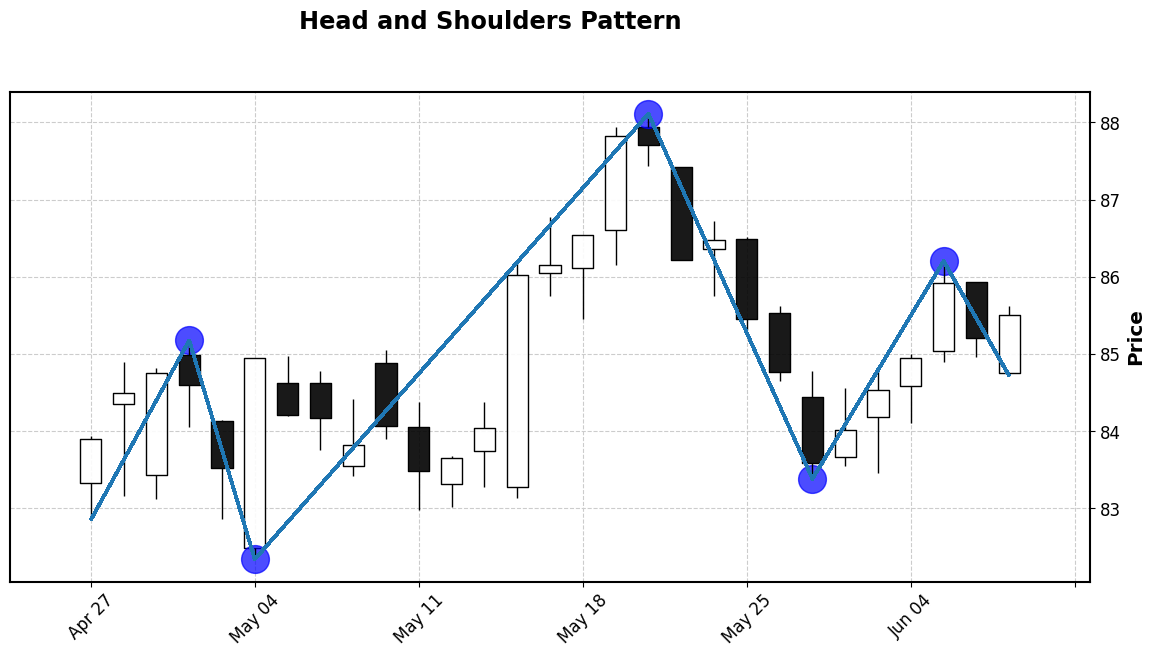

In [12]:
# Initialise the start and end dates for OHLCV data
start_index = data.index.get_loc(hs.dates[0]) - 3
last_index = data.index.get_loc(hs.dates[-1]) + 3

# Fetch the OHLCV data for the period
data_to_plot = data.iloc[start_index:last_index]

# Add pattern details to data_to_plot
data_to_plot['pattern'] = np.nan
data_to_plot.loc[hs.dates, 'pattern'] = hs.price.values

# Define scatter plot to mark the 5 sequential points forming the pattern
hs_plot = mpf.make_addplot(data_to_plot.pattern, type='scatter', marker='o', markersize=400,
                           panel=0, color="blue", alpha=0.7)

# Define subplot of a line that will connect the 5 sequential points
pattern_line = [(data_to_plot.index[0], data.iloc[start_index:data.index.get_loc(hs.dates[0])].min()['Low'])] + list(hs.itertuples(
    index=False, name=None)) + [(data_to_plot.index[-1], data.iloc[data.index.get_loc(hs.dates[-1]):last_index].min()['Low'])]

# Plot the candlestick chart along with pattern-related subplots
mpf.plot(data_to_plot, type='candle', style='classic', addplot=hs_plot,
         title='Head and Shoulders Pattern', figsize=(15, 7), alines=pattern_line)

In [13]:
hs_patterns_data

,sh1_date,neck1_date,head_date,neck2_date,sh2_date,sh1_price,neck1_price,head_price,neck2_price,sh2_price
0,1993-10-06,1993-10-08,1993-10-15,1993-10-25,1993-11-02,27.224736,26.839486,27.683388,27.169702,27.591651
1,2001-05-02,2001-05-04,2001-05-22,2001-05-30,2001-06-05,85.175419,82.340500,88.110491,83.381106,86.202712
2,2003-06-17,2003-07-01,2003-07-14,2003-07-21,2003-07-28,70.218803,66.506732,70.279347,67.486087,69.644837
3,2005-12-14,2005-12-30,2006-01-11,2006-01-25,2006-01-30,91.920951,89.717330,93.382150,90.785015,92.927670
4,2011-08-17,2011-08-22,2011-08-31,2011-09-12,2011-09-20,97.800056,90.707152,99.664096,92.030513,98.946809
5,2014-03-21,2014-03-27,2014-04-04,2014-04-11,2014-04-22,161.603668,157.226256,162.185033,155.011934,161.073550
6,2015-06-22,2015-07-07,2015-07-20,2015-07-27,2015-07-31,186.217163,178.789133,186.733906,180.672454,185.218543
7,2016-04-01,2016-04-07,2016-04-20,2016-05-06,2016-05-11,184.418266,180.812506,187.783649,181.515860,185.664686
8,2018-08-29,2018-09-07,2018-09-21,2018-09-26,2018-10-03,271.376965,266.698077,273.988388,270.428348,273.979057


As you can see in the above graph, we have successfully identified a head and shoulders pattern instance from the OHLCV data of SPY. 

<a id='conclusion'></a>
## Conclusion and Next Steps

You will need the data present in the dataframe `hs_patterns_data` to determine the confirmation date and to set the entry and exit levels for each head and shoulders instance. For this, you can simply you can update the following cell's type to **Code** and run the code line, in order to save the data into a CSV file named `hs_patterns_data.csv`.

In the upcoming Jupyter notebook, you will learn to visualise the entry and exit levels and you will also prepare the data for backtesting the head and shoulders strategy. <br><br>